# 6.3 Metadynamics: Nitric Acid on Graphene

In [1]:
from ecp.style import header, use_style

use_style()
header(
    volume="Volume VI — Reactions and Free Energy",
    number="6.3",
    title="Metadynamics: Nitric Acid on Graphene",
    blurb="Filling the valleys to map the mountains: metadynamics deposits a running "
    "bias along chosen collective variables to push a system out of its basins, and the "
    "accumulated bias reconstructs the free-energy surface of nitric acid interacting "
    "with a graphene sheet.",
    difficulty="advanced",
    estimate="90–120 min",
    source="FS 2023 · Lecture 14 (metadynamics and collective variables)",
)

<ECP header: 2861 chars of HTML>

## Notebook overview

Ordinary molecular dynamics is trapped by barriers: a rare event like a bond breaking
may never happen on a simulable timescale. **Metadynamics** breaks the trap. It picks
a few **collective variables** (CVs), coordinates that describe the slow motion of
interest, and periodically deposits a small repulsive Gaussian **hill** at the
system's current position in CV space. The growing bias fills up whatever basin the
system sits in, eventually floating it over the barrier, and the sum of all the hills,
inverted, *is* the **free-energy surface**.

This is the course's exercise on metadynamics, applied to two nitric-acid molecules
over a graphene sheet, with the fast and cheap **density-functional tight-binding**
(DFTB) method for the forces. We take the course's committed output: the trajectory of
the collective variables (the `COLVAR` log) and the list of deposited hills (the
`HILLS` log). We render the system, follow the collective variables as the bias drives
the exploration, and reconstruct the free-energy surface by summing the hills.

> **Provenance.** This notebook develops **Lecture 14** of the course (metadynamics,
> collective variables, and free-energy surfaces), an exercise **designed by the
> author (Raymond Amador)**. The structure
> (`grly5x3_2hno3.xyz`) and the metadynamics logs (`COLVAR`, `HILLS`) are the course's
> own committed CP2K/DFTB results from a short "simple metadynamics" run. The full
> course credit is in the footer.

> **Reading a validation.** Each task closes with a check against an independent
> fact: the composition of the system, that the bias actually drove exploration, that
> the reconstructed surface is consistent with where the trajectory went. A ✗ flags a
> mismatch; a ✓ is strong evidence, not proof.

> **Scope.** This is a deliberately short teaching run, so the free-energy surface is
> qualitative, the bias filling the explored basin rather than fully converging a
> barrier. Energies are the committed values (Hartree, to kcal/mol). For the method
> see Laio & Parrinello {cite}`laio2002`.

## Theory in brief

### Collective variables

A collective variable $s(\mathbf R)$ is a function of the atomic coordinates chosen to
capture the slow degree of freedom, here **coordination numbers**: a smooth count of
how many atoms of one type lie within a cutoff of another (C–O between graphene and the
acid, N–O within the acid, H–C for a hydrogen approaching the sheet). Coordination
numbers vary continuously as bonds form and break, which makes them good reaction
coordinates.

### The metadynamics bias and the free-energy surface

Every $\tau$ steps a Gaussian of height $W$ and width $\sigma$ is added to the bias at
the current CV value $\mathbf s_t$:

```{math}
:label: eq-metad
V(\mathbf s, t) = \sum_{t' \le t} W \exp\!\left(-\sum_i \frac{(s_i - s_i(t'))^2}{2\sigma_i^2}\right).
```

The bias accumulates in the basins the system visits, raising their floor until the
system spills into the next basin. In the long-time limit the bias becomes the inverse
of the underlying free energy, so the **free-energy surface** is reconstructed simply
by summing the deposited hills and flipping the sign,
$F(\mathbf s) \approx -V(\mathbf s)$.

---
## Setup

In [2]:
import os

import numpy as np
import matplotlib.pyplot as plt

from ecp import validate

INK, AMBER, SOFT = "#16213e", "#c0851a", "#46506b"
HARTREE_KCAL = 627.503
CPK = {"H": "#d9d9d9", "C": "#303030", "O": "#c0392b", "N": "#2c5fb0"}
CV_NAMES = ["C–O coordination", "N–O coordination", "H–C coordination"]


def data_file(name):
    """Locate a shipped data file from the repo root (CI) or the notebook dir (Colab)."""
    for base in ("data", os.path.join("notebooks", "06-reactions-free-energy", "data")):
        path = os.path.join(base, name)
        if os.path.exists(path):
            return path
    raise FileNotFoundError(name)


def read_xyz(name):
    lines = open(data_file(name)).read().splitlines()
    n = int(lines[0].split()[0])
    els = [ln.split()[0] for ln in lines[2:2 + n]]
    xyz = np.array([[float(v) for v in ln.split()[1:4]] for ln in lines[2:2 + n]])
    return els, xyz

## Exercise 1 — The system

The course placed two nitric-acid molecules above a sheet of graphene, 60 carbon atoms
plus the two $\mathrm{HNO_3}$, and ran DFTB molecular dynamics. We render the committed
structure: the flat hexagonal carbon lattice with the small acid molecules hovering
above it. Density-functional tight binding is what makes this affordable, an
approximate, parametrised electronic structure that is orders of magnitude faster than
full DFT, fast enough for the long biased trajectory metadynamics needs.

**Part a)** Render the graphene + nitric-acid system. **Part b)** Confirm its
composition (a carbon sheet plus two HNO₃).

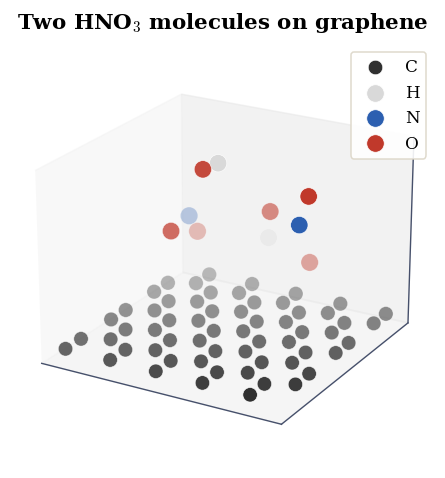

composition: 60×C, 2×H, 2×N, 6×O


In [3]:
# (solution hidden on the public site)


### Validation 1 — graphene plus two nitric-acid molecules

The system must be a carbon sheet (many C) with exactly the atoms of two HNO₃: two N,
six O, two H.

In [4]:
validate.check(
    counts.get("C", 0) >= 50 and counts.get("N") == 2 and counts.get("O") == 6 and counts.get("H") == 2,
    "the system is graphene plus two nitric-acid molecules",
    f"composition {counts}",
)

✓  the system is graphene plus two nitric-acid molecules   [composition {'C': 60, 'H': 2, 'N': 2, 'O': 6}]


True

## Exercise 2 — The collective variables over time

The `COLVAR` log records the three collective variables at every step. Plotting them
against time (Assignment 3) shows metadynamics at work: the bias progressively pushes
the system away from where it has already been, so the CVs wander over a growing range
rather than fluctuating around a fixed point as they would in plain dynamics.

**Part a)** Load `COLVAR` and plot the three CVs against time. **Part b)** Confirm the
bias has driven each CV over a finite range.

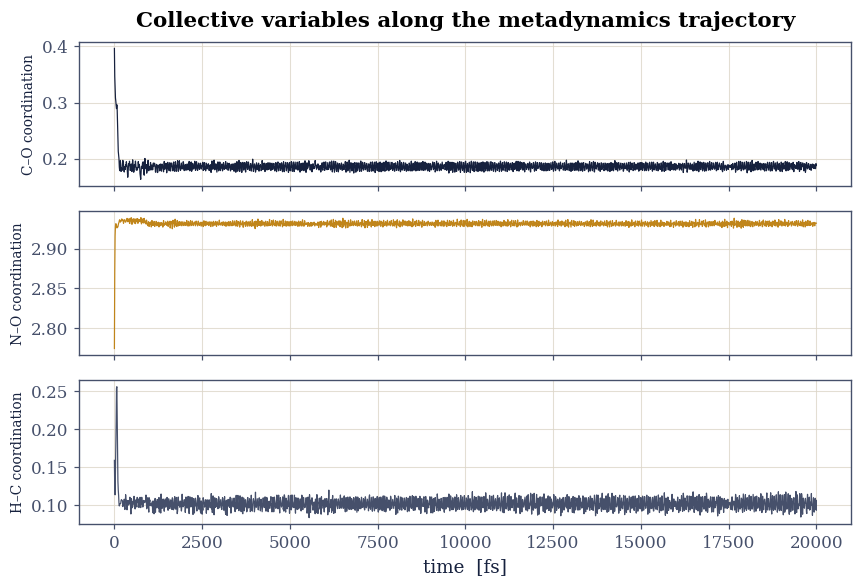

CV explored ranges: {'C–O coordination': np.float64(0.234), 'N–O coordination': np.float64(0.165), 'H–C coordination': np.float64(0.171)}


In [5]:
# (solution hidden on the public site)


### Validation 2 — the bias drove exploration

Metadynamics must move the system: every collective variable has to explore a finite
range over the run, not sit at a single value.

In [6]:
validate.check(
    bool(np.all(cv_ranges > 0.05)),
    "all three collective variables explore a finite range",
    f"ranges {cv_ranges.round(3)} (CV units)",
)

✓  all three collective variables explore a finite range   [ranges [0.234 0.165 0.171] (CV units)]


True

## Exercise 3 — Reconstructing the free-energy surface

The `HILLS` log lists every deposited Gaussian: its centre in CV space, its widths,
and its height. Summing them and flipping the sign reconstructs the free-energy surface
{eq}`eq-metad` (Assignment 4). We project onto two of the variables, the C–O and H–C
coordinations that describe the acid approaching and bonding to the sheet, and contour
the result. The minimum marks the most-visited configuration; because this is a short
run the surface maps the explored basin rather than a fully converged barrier.

**Part a)** Load `HILLS` and reconstruct the 2-D free-energy surface. **Part b)**
Confirm its minimum coincides with where the trajectory spent the most time.

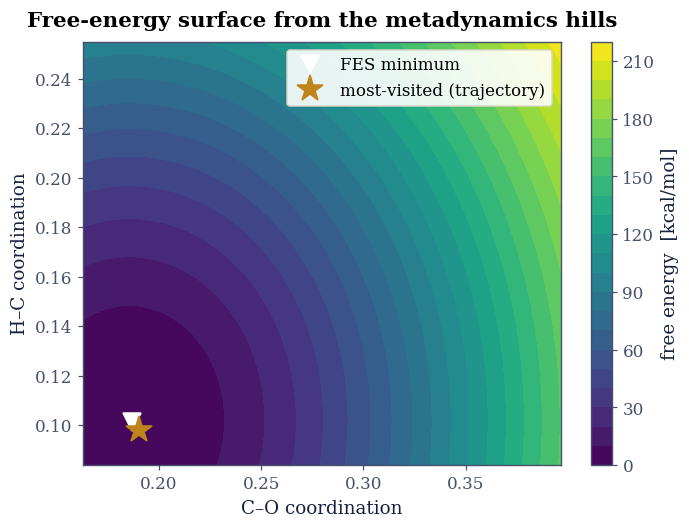

FES minimum at (0.19, 0.10); most-visited at (0.19, 0.10)


In [7]:
# (solution hidden on the public site)


### Validation 3 — the surface is consistent with the trajectory

Metadynamics fills the basins it visits, so the reconstructed free-energy minimum must
coincide with where the trajectory actually spent its time, a consistency check
between the `HILLS` reconstruction and the independent `COLVAR` trajectory.

In [8]:
span = np.hypot(np.ptp(cv[:, a]), np.ptp(cv[:, b]))
validate.check(
    agreement < 0.25 * span,
    "the reconstructed FES minimum sits where the trajectory spent the most time",
    f"FES min ↔ most-visited distance = {agreement:.3f} ({100*agreement/span:.0f}% of the explored span)",
)

✓  the reconstructed FES minimum sits where the trajectory spent the most time   [FES min ↔ most-visited distance = 0.005 (2% of the explored span)]


True

## Notebook summary

We followed a metadynamics run of nitric acid over graphene, computed with
density-functional tight binding. The three coordination-number collective
variables wandered over a growing range as the accumulating bias pushed the system
through configuration space, and summing the deposited Gaussian hills reconstructed
the free-energy surface. Its minimum coincided with the trajectory's most-visited
configuration, a consistency check between the HILLS reconstruction and the
independent COLVAR record; a longer run would extend the surface to the dissociated
basin across the barrier.

## Outlook

- **Convergence.** A converged free-energy surface needs the bias to grow flat; the
  short run here does not reach that. **Well-tempered** metadynamics shrinks the hills
  over time and converges cleanly.
- **Choosing CVs.** The result is only as good as the collective variables: a CV that
  misses the true slow mode leaves a hidden barrier. The exercise's four candidate CVs
  (coordination numbers and a point-to-plane distance) are a study in that choice.
- **The dissociation.** With a longer run the H–O bond of nitric acid breaks and the
  proton transfers, the dissociation the exercise is named for, appearing as a second
  basin across a barrier in the H–C coordination.
- **Reweighting.** The deposited bias can be used to reweight the trajectory back to
  unbiased ensemble averages of other observables.

### References

```{bibliography}
:filter: docname in docnames
```

In [9]:
from ecp.style import footer

footer()

<ECP header: 1690 chars of HTML>